#  1 Loading Accident Data

In [1]:
import numpy as np
data = np.loadtxt("coal_mining_accident_data.dat", delimiter=None)  
data =  data.flatten() # Now all data is in a single array 190 delimiters for 191 incidents
print(data.shape)
# print(data)

(190,)


[  1.   1.   1. ... 190. 190. 191.]


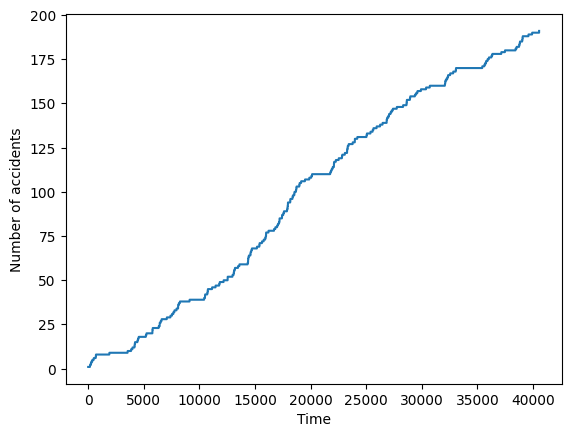

In [2]:
# Plot cumulative sum of accidents over time
import matplotlib.pyplot as plt
cumulative_accidents = np.zeros(40550) # Start with the first accident
cumulative_accidents[0] = 1
i = 0 
j = 0 # next
for interval in data:
    start = cumulative_accidents[i]
    j += int(interval)
    while i < j:
        cumulative_accidents[i] = start
        i += 1 # This ends when i == j
    cumulative_accidents[j] = start + 1

print(cumulative_accidents)
plt.plot(range(40550), cumulative_accidents)
plt.xlabel("Time")
plt.ylabel("Number of accidents")
plt.show()


# 2a Plain vs Even order stats

The plain-order-statistics draws k points and sorts them. This allows the adjacent points to be very close together. By drawing more points than required and then taking alterating points from a sorted array of them, this forces a degree of seapration between the change points we are using as a prior. This reduces the probability of very small gaps between neighbours, favouring more separated change points.

This can improve performance because it encourages the model to use all of the change points: if two change points are too close together in the prior, the model might fit them as one.

In [ ]:
np.random.seed(1701)

def find_gaps(samples, L=40550):
    left = [0]
    right = [L]
    full = np.concatenate([left, samples, right])
    gaps = [(full[i] - full[i-1]) for i in range(1, len(full))]
    return gaps

def even_stats(k=4, L=40550):
    even_rand = [np.random.uniform() for i in range((2*k+1))]
    even_sorted = np.sort(even_rand)
    even_unscaled = even_sorted[1::2]    
    even = even_unscaled * L
    return even

def plain_stats(k=4, L=40550):
    plain_rand = [np.random.uniform() for i in range(k)]
    plain_unscaled = np.sort(plain_rand) 
    plain = plain_unscaled * L
    return plain


[ 3626.51765186  8630.75052304 21035.06661331 35683.30688448]
[ 6913.10752386 13351.78739706 13357.34922427 27637.26818534]


C:\Users\Joey\AppData\Local\Temp\ipykernel_30084\2135258418.py:23: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


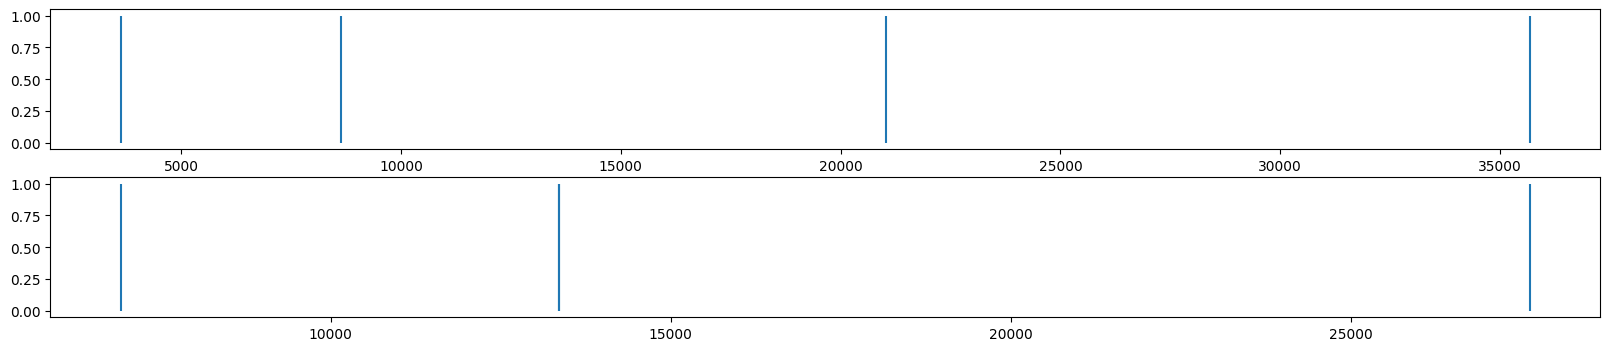

In [4]:
# Plot single example
np.random.seed(1701)
k = 4

# Even order stats
# even_rand = [np.random.uniform() for i in range((2*k+1))]
# even_sorted = np.sort(even_rand)
# even = even_sorted[1::2]
even = even_stats()

# Plain stats
# plain_rand = [np.random.uniform() for i in range(k)]
# plain = np.sort(plain_rand)
plain = plain_stats()

print(even)
print(plain)

fig, ax = plt.subplots(2, figsize=(20, 4))

ax[0].vlines(even, 0, 1)
ax[1].vlines(plain,0, 1)
fig.show()




The middle line on the plain-statistics draw (the bottom subplot) shows is actually two draws that are very close to one another. We can try to look at this for a larger number of draws by plotting the distribution of the size of gaps between the generated change points.

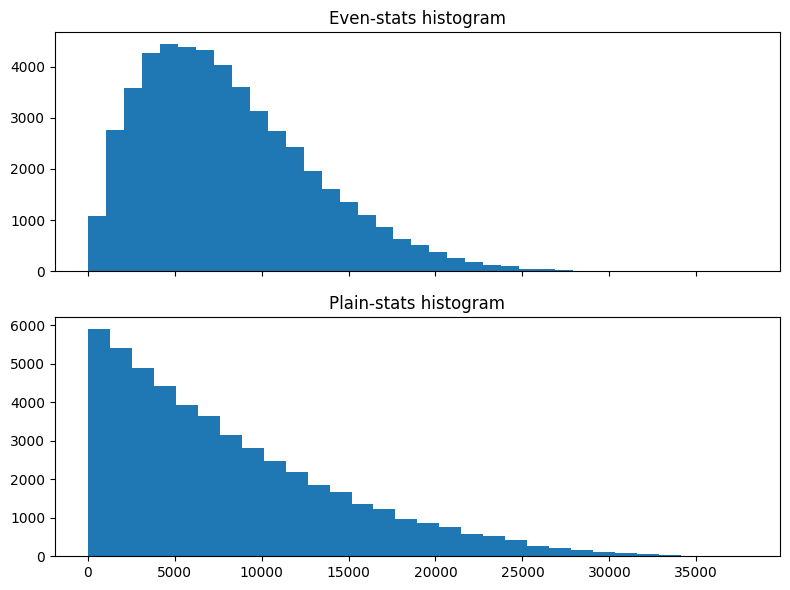

In [ ]:
even_gaps = []
plain_gaps =[]
for i in range(0,10000):
    even_gaps.append(find_gaps(even_stats(k=4)))
    plain_gaps.append(find_gaps(plain_stats(k=4)))

even_gaps = np.array(even_gaps).flatten()
plain_gaps = np.array(plain_gaps).flatten()

# Plot them in two subplot histograms

fig, axs = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

axs[0].hist(even_gaps, bins=30)
axs[0].set_title("Even-stats histogram")

axs[1].hist(plain_gaps, bins=30)
axs[1].set_title("Plain-stats histogram")

plt.tight_layout()
plt.show()

This shows that our even-stats regime reduces the probability of very close together initial change-points. To have very high separations, the points have to be clumped at the ends so the reduction in clumping behaviour will also have the side effect of reducing very separated points too. This creates a consistent separation between change points.

# 2b Even-order statistics prior analysis

COME BACK TO THIS HOPO HOPO


# 3 Constant Rate Model
Model $M_0$ has constant rate $h_0$.
- k = 0 means no change points
- The heights are iid from $\Gamma(\alpha,\beta)$
- $\alpha = 1$, $\beta = 200$
- $P(h)=\frac{\beta^\alpha}{\Gamma(\alpha)} e^{-\beta h}, \qquad h>0$ is then the prior over $h_0$ in model $M_0$: $\pi(h_0|M_0)$
- The posterior $P(h_0|\{I_i\},M_0) = \frac{}{}$


-1217.0924811139914
-1210.022781756996
0.0


C:\Users\Joey\AppData\Local\Temp\ipykernel_30084\1808235911.py:34: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


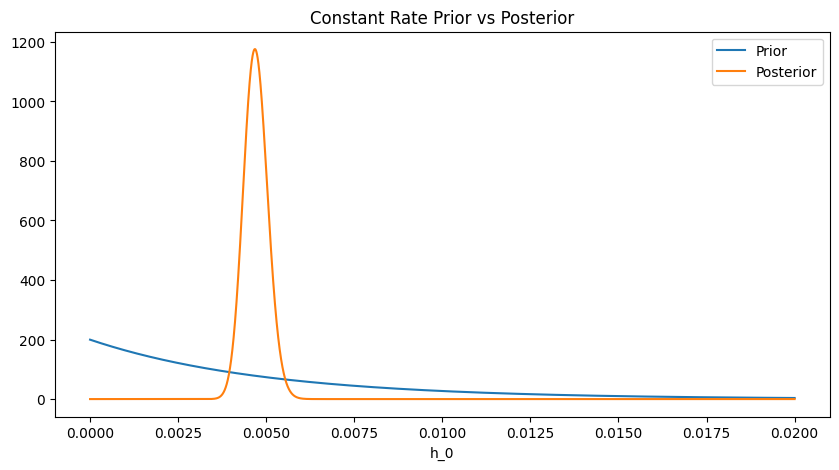

In [6]:
# Prior
def cr_prior(h_0):
    return 200 * np.exp(-200 * h_0)

# Integrand
def cr_LnPiL(h_0):
    return np.log(200) + 191 * np.log(h_0) + -40750 * h_0

# Calculate Z
h_0_vals = np.linspace(1e-5, 0.02, 20000, dtype=np.longdouble)
cr_prior_vals = cr_prior(h_0_vals)
cr_LnPiL_vals = cr_LnPiL(h_0_vals)
m = max(cr_LnPiL_vals)
cr_LnPiL_vals_shift = cr_LnPiL_vals - m
unscaled_z = np.trapezoid(np.exp(cr_LnPiL_vals_shift), h_0_vals)
log_z = m + np.log(unscaled_z)
print(log_z)

z = np.exp(m) * unscaled_z

print(m)
print(z)

log_post = cr_LnPiL(h_0_vals) - log_z
cr_post = np.exp(log_post)

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(h_0_vals, cr_prior_vals, label="Prior")
ax.plot(h_0_vals, cr_post, label="Posterior")
ax.set_xlabel("h_0")
ax.set_title("Constant Rate Prior vs Posterior")
ax.legend()
fig.show()

# fig, ax = plt.subplots(1,2, figsize=(10, 5))
# ax[0].plot(h_0_vals, cr_prior_vals, label="Prior")
# ax[1].plot(h_0_vals, cr_post, label="Posterior")
# ax[0].set_xlabel("h_0")
# ax[1].set_xlabel("h_0")
# ax[0].set_title("Constant Rate Prior")
# ax[1].set_title("Posterior")
# fig.show()



# 4a

In [ ]:
# For the log likelihoods it will be useful to have an array that has the cumulative days since 0 for each of the 191 accidents
cumulative_days = np.concatenate([[0], np.cumsum(data)]) #The array indices of the days on which accidents occurred (days-1)
len(data)
print(cumulative_days) #If we start at day 0 the final day will be numbered 549

[    0.   157.   222.   275.   368.   495.   671.   693.  1898.  3541.
  3853.  3976.  4162.  4179.  4203.  4421.  4476.  4537.  5181.  5235.
  5771.  5773.  5796.  6334.  6425.  6427.  6520.  6598.  7065.  7391.
  7536.  7660.  7752.  7939.  8082.  8082.  8141.  8240.  9111. 10423.
 10498. 10510. 10707. 10741. 10757. 11135. 11450. 11776. 11824. 12172.
 12536. 12540. 12971. 13072. 13099. 13135. 13194. 13469. 13592. 14337.
 14374. 14384. 14400. 14441. 14585. 14600. 14661. 14715. 15171. 15388.
 15407. 15623. 15777. 15916. 15961. 15992. 15993. 16210. 16708. 16828.
 16984. 17064. 17159. 17201. 17207. 17422. 17435. 17548. 17597. 17872.
 17919. 17931. 17956. 17957. 18165. 18176. 18365. 18397. 18528. 18548.
 18677. 18710. 18729. 18979. 19008. 19145. 19490. 19878. 20060. 20126.
 21756. 21822. 21900. 21980. 22092. 22096. 22116. 22267. 22522. 22814.
 22843. 23075. 23277. 23280. 23323. 23338. 23419. 23780. 23974. 23978.
 24195. 25021. 25057. 25381. 25574. 25646. 25932. 26244. 26468. 26836.
 26843

In [ ]:
from scipy.special import gammaln
def LnPi(change_points, heights, L=40550): # there should be k change points and k+1 heights
    k = len(change_points)
    alpha = np.ones(k+1) * 2
    gaps = find_gaps(change_points) # there should be k+1 gaps
    ln_gaps = np.log(gaps)
    sum_ln_gaps = np.sum(ln_gaps)
    lnB = np.sum(gammaln(alpha)) - gammaln(np.sum(alpha))
    change_portion = (-1 * (2*k + 1)*np.log(L)) - lnB + sum_ln_gaps  # the contribution of the change points to the prior
    height_portion = ((k+1) * np.log(200)) - (200 * np.sum(heights))
    return height_portion + change_portion

def LnL(change_points, heights, L=40550): # The data is in put in the cumdays array
    cp = np.array(change_points)
    h = np.array(heights)
    k = len(change_points)
    log_term = 0
    modified_change_points= np.concatenate([[0], change_points, [L]])
    i = 0 # index for cumulative days
    j = 0 # change points index
    while j <= k: # there are k change points
        if cumulative_days[i] > modified_change_points[j]  and cumulative_days[i] < modified_change_points[j+1]:
            log_term += np.log(heights[j])
            i += 1
        else:
            j += 1
        
    bounds = np.concatenate(([0.0], cp, [float(L)]))
    segment_lengths = np.diff(bounds)

    # count which segment each accident falls into
    seg_idx = np.searchsorted(cp, np.array(cumulative_days), side="right")

    log_term = np.sum(np.log(h[seg_idx]))
    integral_term = np.sum(h * segment_lengths)

    return log_term - integral_term

# Combine into log posterior
def LnPost(change_points, heights, L=40550):
    LnPost = LnPi(change_points, heights, L) 
    if not np.isfinite(LnPost):
        return -np.inf
    return LnPost + LnL(change_points, heights, L)






In [8]:
np.ones(2)

array([1., 1.])